In [1]:
# CELL 1: Setup

import cv2
import numpy as np
import os, glob, json, re, random, string, warnings
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from collections import Counter
import urllib.request
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)

os.makedirs('/kaggle/working/extracted_symbols', exist_ok=True)
os.makedirs('/kaggle/working/visualizations', exist_ok=True)
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
# CELL 2 (v4): Smart Symbol Detection + Density Filter

import cv2
import numpy as np
import os, glob, json
from pathlib import Path

os.makedirs('/kaggle/working/extracted_symbols', exist_ok=True)
os.makedirs('/kaggle/working/visualizations', exist_ok=True)
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)

IMAGE_DIR = '/kaggle/input/datasets/mahmudaaktersristy/fydp-3-dataset/input_photos/'

def remove_lines(binary):
    h, w = binary.shape
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (w // 5, 1))
    h_lines  = cv2.morphologyEx(binary, cv2.MORPH_OPEN, h_kernel)
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, h // 5))
    v_lines  = cv2.morphologyEx(binary, cv2.MORPH_OPEN, v_kernel)
    return cv2.subtract(binary, cv2.add(h_lines, v_lines))

def preprocess(image_path):
    img  = cv2.imread(str(image_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    gray  = clahe.apply(gray)
    gray  = cv2.GaussianBlur(gray, (3, 3), 0)
    binary = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 13, 4
    )
    binary = remove_lines(binary)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (4, 4))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k, iterations=1)
    return img, binary

def is_valid_crop(crop, min_density=0.04, max_density=0.85):
    """Filter out empty boxes (erased text, white space) and solid noise"""
    density = np.sum(crop > 127) / crop.size
    return min_density < density < max_density

def boxes_close(b1, b2, gap=6):
    x1,y1,w1,h1 = b1
    x2,y2,w2,h2 = b2
    return not (x1+w1+gap < x2 or x2+w2+gap < x1 or
                y1+h1+gap < y2 or y2+h2+gap < y1)

def smart_merge(boxes, max_sym):
    boxes   = list(boxes)
    changed = True
    while changed:
        changed = False
        result  = []
        used    = [False] * len(boxes)
        for i in range(len(boxes)):
            if used[i]:
                continue
            cur = list(boxes[i])
            used[i] = True
            for j in range(len(boxes)):
                if used[j] or i == j:
                    continue
                if boxes_close(tuple(cur), boxes[j], gap=6):
                    x2,y2,w2,h2 = boxes[j]
                    nx = min(cur[0], x2)
                    ny = min(cur[1], y2)
                    nw = max(cur[0]+cur[2], x2+w2) - nx
                    nh = max(cur[1]+cur[3], y2+h2) - ny
                    if nw <= max_sym and nh <= max_sym:
                        cur     = [nx, ny, nw, nh]
                        used[j] = True
                        changed = True
            result.append(tuple(cur))
        boxes = result
    return boxes

def extract_symbols(image_path):
    img, binary  = preprocess(image_path)
    h_img, w_img = img.shape[:2]

    max_sym  = min(w_img, h_img) // 4
    min_area = 80
    max_area = max_sym * max_sym

    contours, _ = cv2.findContours(
        binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    raw_boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if min_area < area < max_area:
            x, y, w, h = cv2.boundingRect(cnt)
            ar = w / (h + 1e-5)
            if 0.08 < ar < 12:
                raw_boxes.append((x, y, w, h))

    merged = smart_merge(raw_boxes, max_sym)

    crops       = []
    final_boxes = []
    debug       = img.copy()
    padding     = 6

    for (x, y, w, h) in merged:
        if w * h < min_area:
            continue
        ar = w / (h + 1e-5)
        if not (0.1 < ar < 10):
            continue

        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(w_img, x + w + padding)
        y2 = min(h_img, y + h + padding)

        crop = binary[y1:y2, x1:x2]
        crop = cv2.resize(crop, (64, 64))

        # DENSITY FILTER: reject empty/erased boxes
        if not is_valid_crop(crop):
            continue

        crops.append(crop)
        final_boxes.append((x, y, w, h))
        cv2.rectangle(debug, (x1, y1), (x2, y2), (0, 255, 0), 2)

    return crops, final_boxes, debug

image_paths = sorted(
    glob.glob(IMAGE_DIR + '*.jpeg') +
    glob.glob(IMAGE_DIR + '*.jpg')
)

all_crops    = []
all_metadata = []
counter      = 0

for path in image_paths:
    crops, boxes, debug = extract_symbols(path)
    name = Path(path).name
    print(f"{name} -> {len(crops)} symbols")
    cv2.imwrite(
        f'/kaggle/working/visualizations/debug_{Path(path).stem}.png',
        debug
    )
    for crop, box in zip(crops, boxes):
        all_crops.append(crop)
        all_metadata.append({
            'id'          : counter,
            'source_image': name,
            'bbox'        : list(box)
        })
        cv2.imwrite(
            f'/kaggle/working/extracted_symbols/sym_{counter:04d}.png',
            crop
        )
        counter += 1

with open('/kaggle/working/checkpoints/all_metadata.json', 'w') as f:
    json.dump(all_metadata, f)
np.save('/kaggle/working/checkpoints/all_crops.npy', np.array(all_crops))

print(f"\nTotal symbols extracted: {counter}")

img1.jpeg -> 73 symbols
img2.jpeg -> 57 symbols
img3.jpeg -> 27 symbols
img4.jpeg -> 95 symbols
img5.jpeg -> 88 symbols
img6.jpeg -> 107 symbols
img7.jpeg -> 79 symbols

Total symbols extracted: 526


# STEP 2 — Multilingual + Variable-Length Dataset

In [17]:
# CELL 3: Download 5 languages + Wikipedia (diverse)

import urllib.request, json

def download_text(url):
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=30) as r:
            return r.read().decode('utf-8', errors='ignore')
    except Exception as e:
        print(f"    Failed: {e}")
        return ""

def get_wikipedia(title):
    try:
        url = f"https://en.wikipedia.org/w/api.php?action=query&prop=extracts&explaintext=true&titles={title}&format=json"
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=15) as r:
            data = json.loads(r.read().decode())
            pages = data['query']['pages']
            for page in pages.values():
                return page.get('extract', '')
    except:
        return ''

# 5 languages
gutenberg = {
    'english': [
        'https://www.gutenberg.org/files/46/46-0.txt',
        'https://www.gutenberg.org/files/1661/1661-0.txt',
        'https://www.gutenberg.org/files/84/84-0.txt',
        'https://www.gutenberg.org/files/98/98-0.txt',
        'https://www.gutenberg.org/files/1342/1342-0.txt',
        'https://www.gutenberg.org/files/74/74-0.txt',
        'https://www.gutenberg.org/files/11/11-0.txt',
        'https://www.gutenberg.org/files/2701/2701-0.txt',
    ],
    'finnish' : ['https://www.gutenberg.org/files/7000/7000-8.txt'],
    'latin'   : ['https://www.gutenberg.org/files/10657/10657-0.txt'],
    'turkish' : ['https://www.gutenberg.org/cache/epub/2000/pg2000.txt'],
    'spanish' : [
        'https://www.gutenberg.org/files/2000/2000-0.txt',
        'https://www.gutenberg.org/files/15532/15532-0.txt',
    ],
}

wiki_topics = [
    'Mathematics','Physics','Computer_science','Machine_learning',
    'Artificial_intelligence','Biology','Chemistry','Medicine',
    'Python_(programming_language)','University','Education',
    'Association_football','Cricket','Basketball',
    'Bangladesh','India','History','Geography',
    'Food','Health','Engineering','Philosophy',
    'Muhammad_Ali','Mahatma_Gandhi','Marie_Curie',
]

corpora = {}
for lang, urls in gutenberg.items():
    print(f"\nDownloading {lang}...")
    text = ""
    for url in urls:
        t = download_text(url)
        if t and len(t) > 5000:
            text += t
            print(f"  +{len(t):,} chars")
    corpora[lang] = text

print("\nDownloading Wikipedia...")
wiki_text = ""
for topic in wiki_topics:
    t = get_wikipedia(topic)
    if t and len(t) > 100:
        wiki_text += t + "\n"
        print(f"  +{len(t):,} chars: {topic}")
corpora['english'] += wiki_text

print(f"\nTotal: {sum(len(v) for v in corpora.values()):,} chars")
for lang, text in corpora.items():
    print(f"  {lang:10}: {len(text):,} chars")


  +181,887 chars
  +593,731 chars
  +419,434 chars
  +757,702 chars
  +728,846 chars
  +392,888 chars
  +144,696 chars
  +1,219,043 chars

  +613,907 chars

  +944,754 chars

  +2,168,117 chars

  +2,168,460 chars
    Failed: HTTP Error 404: Not Found

  +56,499 chars: Mathematics
  +36,292 chars: Physics
  +30,144 chars: Computer_science
  +58,652 chars: Machine_learning
  +84,784 chars: Artificial_intelligence
  +11,592 chars: Biology
  +44,656 chars: Chemistry
  +56,321 chars: Medicine
  +40,451 chars: Python_(programming_language)
  +38,928 chars: University

Total: 10,791,794 chars
  english   : 4,896,556 chars
  finnish   : 613,907 chars
  latin     : 944,754 chars
  turkish   : 2,168,117 chars
  spanish   : 2,168,460 chars


In [4]:
# CELL 3B: Download Latin alternative

latin_urls = [
    'https://www.gutenberg.org/files/10657/10657-0.txt',
    'https://www.gutenberg.org/files/2201/2201.txt',
    'https://www.gutenberg.org/cache/epub/10657/pg10657.txt',
]

latin_text = ""
for url in latin_urls:
    print(f"Trying: {url}")
    text = download_text(url)
    if text and len(text) > 10000:
        latin_text = text
        print(f"  Success: {len(text)} chars")
        break
    else:
        print(f"  Failed or too short")

if latin_text:
    corpora['latin'] = latin_text
else:
    print("Latin not available — using English corpus twice (acceptable)")
    corpora['latin'] = corpora['english']

print(f"\nFinal languages: {list(corpora.keys())}")
print(f"Total: {sum(len(v) for v in corpora.values())} chars")

Trying: https://www.gutenberg.org/files/10657/10657-0.txt
  Success: 944754 chars

Final languages: ['english', 'finnish', 'latin', 'turkish']
Total: 8623334 chars


In [39]:
# CELL 4: Clean + Build Statistical N-gram Model
# (REPLACES NEURAL LM - No GPU training needed!)

import re
from collections import defaultdict, Counter
import math, json

LANG_CHARS = {
    'english': set('abcdefghijklmnopqrstuvwxyz'),
    'finnish': set('abcdefghijklmnopqrstuvwxyzäöå'),
    'latin'  : set('abcdefghijklmnopqrstuvwxyz'),
    'turkish': set('abcdefghijklmnopqrstuvwxyzçğışöü'),
    'spanish': set('abcdefghijklmnopqrstuvwxyzáéíóúñü'),
}

def clean_corpus(text, valid_chars):
    return ''.join(c for c in text.lower() if c in valid_chars)

cleaned  = {}
all_chars = set()

for lang, text in corpora.items():
    valid    = LANG_CHARS.get(lang, set('abcdefghijklmnopqrstuvwxyz'))
    c        = clean_corpus(text, valid)
    cleaned[lang] = c
    all_chars.update(set(c))
    print(f"{lang:10}: {len(c):>10} chars | unique: {sorted(set(c))}")

vocab_chars = sorted(all_chars)
char_to_id  = {c: i for i, c in enumerate(vocab_chars)}
id_to_char  = {i: c for c, i in char_to_id.items()}
VOCAB_SIZE  = len(vocab_chars)
print(f"\nVocabulary ({VOCAB_SIZE} chars): {vocab_chars}")

combined_text = ''.join(cleaned.values())
print(f"Combined  : {len(combined_text):,} chars")

# === BUILD STATISTICAL N-GRAM MODEL (from English corpus) ===
print("\nBuilding n-gram language model from English corpus...")
eng = combined_text  

unigram_count = Counter(eng)
bigram_count  = Counter(eng[i:i+2] for i in range(len(eng)-1))
trigram_count = Counter(eng[i:i+3] for i in range(len(eng)-2))

SMOOTH = 0.5
V      = VOCAB_SIZE

def get_bigram_llh(sequence):
    """Average bigram log-likelihood → closer to 0 = more language-like"""
    if len(sequence) < 2:
        return math.log(SMOOTH / (sum(unigram_count.values()) + SMOOTH * V))
    chars = [id_to_char.get(s, id_to_char.get(str(s), 'a')) for s in sequence]
    total = 0
    for i in range(len(chars)-1):
        a, b      = chars[i], chars[i+1]
        ctx_count = unigram_count.get(a, 0) + SMOOTH * V
        bi_count  = bigram_count.get(a+b, 0) + SMOOTH
        total    += math.log(bi_count / ctx_count)
    return total / (len(sequence)-1)

def get_trigram_llh(sequence):
    """Average trigram log-likelihood"""
    if len(sequence) < 3:
        return math.log(SMOOTH / (sum(bigram_count.values()) + SMOOTH * V))
    chars = [id_to_char.get(s, id_to_char.get(str(s), 'a')) for s in sequence]
    total = 0
    for i in range(len(chars)-2):
        a, b, c   = chars[i], chars[i+1], chars[i+2]
        ctx_count = bigram_count.get(a+b, 0) + SMOOTH * V
        tri_count = trigram_count.get(a+b+c, 0) + SMOOTH
        total    += math.log(tri_count / ctx_count)
    return total / (len(sequence)-2)

# Quick test
test_text = "thequickbrownfoxjumpsoverthelazydog"
test_ids  = [char_to_id[c] for c in test_text if c in char_to_id]
print(f"\nBigram LLH test (natural English) : {get_bigram_llh(test_ids):.4f}")

cipher_text = "wkhtxlfneurzqiradftjvbsmopnlygkzx"
cipher_ids  = [char_to_id[c] for c in cipher_text if c in char_to_id]
print(f"Bigram LLH test (cipher)          : {get_bigram_llh(cipher_ids):.4f}")

random_ids  = [random.randint(0, VOCAB_SIZE-1) for _ in range(len(test_ids))]
print(f"Bigram LLH test (random)          : {get_bigram_llh(random_ids):.4f}")


# Build separate language models
print("\nBuilding per-language bigram models...")
lang_models = {}
for lang, text in cleaned.items():
    if len(text) > 5000:
        bi_count  = Counter(text[i:i+2] for i in range(len(text)-1))
        uni_count = Counter(text)
        lang_models[lang] = {'bigram': bi_count, 'unigram': uni_count}
        print(f"  {lang}: {len(bi_count)} bigrams")

def get_max_lang_bigram_llh(sequence):
    """Max bigram LLH across all language models — correct multilingual approach"""
    if len(sequence) < 2:
        return -10.0
    chars = [id_to_char.get(s, id_to_char.get(str(s), 'a')) for s in sequence]
    best  = -999
    for lang, model in lang_models.items():
        total = 0
        bi = model['bigram']
        uni = model['unigram']
        for i in range(len(chars)-1):
            a, b      = chars[i], chars[i+1]
            ctx       = uni.get(a, 0) + SMOOTH * V
            cnt       = bi.get(a+b, 0) + SMOOTH
            total    += math.log(cnt / ctx)
        score = total / (len(sequence)-1)
        if score > best:
            best = score
    return best

# Test
print(f"\nMax LLH — English : {get_max_lang_bigram_llh(text_to_ids('thequickbrownfox')):.3f}")
print(f"Max LLH — Turkish : {get_max_lang_bigram_llh(text_to_ids('istanbulbüyükve')):.3f}")
print(f"Max LLH — Finnish : {get_max_lang_bigram_llh(text_to_ids('helsingissäon')):.3f}")
print(f"Max LLH — Cipher  : {get_max_lang_bigram_llh(text_to_ids('wkhehvwriwlphv')):.3f}")


# Save
with open('/kaggle/working/checkpoints/char_mapping.json', 'w') as f:
    json.dump({
        'char_to_id' : char_to_id,
        'id_to_char' : {str(k): v for k, v in id_to_char.items()},
        'vocab_size'  : VOCAB_SIZE,
        'vocab_chars' : vocab_chars,
    }, f, ensure_ascii=False)

with open('/kaggle/working/checkpoints/cleaned_corpora.json', 'w') as f:
    json.dump({'cleaned': cleaned, 'vocab_chars': vocab_chars}, f, ensure_ascii=False)

print("\nSaved.")

english   :    3800367 chars | unique: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
finnish   :     446060 chars | unique: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
latin     :     734729 chars | unique: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
turkish   :    1624951 chars | unique: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'ü']
spanish   :    1666982 chars | unique: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'á', 'é', 'í', 'ñ', 'ó', 'ú', 'ü']

Vocabulary (33 chars): ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 

In [34]:
# CELL 5 (FINAL): Balanced Sequence Generation — No shortcuts

import random, json
random.seed(42)

def text_to_ids(text):
    return [char_to_id[c] for c in text if c in char_to_id]

def caesar(text, shift):
    return [(char_to_id[c] + shift) % VOCAB_SIZE for c in text if c in char_to_id]

def vigenere(text, key):
    key_ids = [char_to_id[k] for k in key if k in char_to_id]
    result, ki = [], 0
    for c in text:
        if c in char_to_id:
            result.append((char_to_id[c] + key_ids[ki % len(key_ids)]) % VOCAB_SIZE)
            ki += 1
    return result

def substitution_cipher(text):
    perm = list(range(VOCAB_SIZE))
    random.shuffle(perm)
    return [perm[char_to_id[c]] for c in text if c in char_to_id]

def transposition_cipher(text, block):
    ids = [char_to_id[c] for c in text if c in char_to_id]
    result = []
    for i in range(0, len(ids)-block+1, block):
        result.extend(ids[i:i+block][::-1])
    return result

def affine_cipher(text, a, b):
    return [(a*char_to_id[c]+b) % VOCAB_SIZE for c in text if c in char_to_id]

LENGTHS = (
    [6, 8, 10, 12, 15, 18, 20, 22, 25] * 5 +
    [30, 40, 50, 75, 100] * 3 +
    [150, 200]
)
REPEAT = 40
keys   = ['secret', 'ancient', 'decode', 'stone', 'cipher', 'mystery']

all_sequences = {k: [] for k in ['language', 'cipher', 'random', 'decorative']}

for _ in range(REPEAT):
    for length in LENGTHS:

        # === Language: random chunk from diverse corpus ===
        start = random.randint(0, max(0, len(combined_text) - length * 2))
        ids   = text_to_ids(combined_text[start:start + length * 2])[:length]
        if len(ids) >= max(3, length // 2):
            all_sequences['language'].append({'ids': ids, 'length': len(ids)})

        # === Cipher: 5 types, randomly selected ===
        start = random.randint(0, max(0, len(combined_text) - length * 2))
        chunk = combined_text[start:start + length * 2][:length]
        ct    = random.randint(0, 4)
        if ct == 0:
            enc = caesar(chunk, random.randint(1, VOCAB_SIZE - 1))
        elif ct == 1:
            enc = vigenere(chunk, random.choice(keys))
        elif ct == 2:
            enc = substitution_cipher(chunk)
        elif ct == 3:
            enc = transposition_cipher(chunk, random.randint(3, 8))
        else:
            a   = random.choice([3, 5, 7, 9, 11, 13, 17, 19, 23, 25])
            enc = affine_cipher(chunk, a, random.randint(1, VOCAB_SIZE - 1))
        if enc:
            all_sequences['cipher'].append({
                'ids'   : enc[:length],
                'length': len(enc[:length])
            })

        # === Random: purely random IDs ===
        ids = [random.randint(0, VOCAB_SIZE - 1) for _ in range(length)]
        all_sequences['random'].append({'ids': ids, 'length': length})

        # === Decorative: 1-3 symbols repeated ===
        if random.random() < 0.55:
            pat = random.sample(range(VOCAB_SIZE), random.randint(1, 3))
            seq = []
            while len(seq) < length:
                seq.extend(pat)
            all_sequences['decorative'].append({
                'ids'   : seq[:length],
                'length': length
            })

print("Sequence counts:")
for k, v in all_sequences.items():
    lengths = [s['length'] for s in v]
    print(f"  {k:<12}: {len(v):5d} | avg_len={sum(lengths)/len(lengths):.1f} | "
          f"min={min(lengths)} max={max(lengths)}")

total = sum(len(v) for v in all_sequences.values())
print(f"\n  Total     : {total}")

with open('/kaggle/working/checkpoints/all_sequences.json', 'w') as f:
    json.dump(all_sequences, f)
print("Saved.")

Sequence counts:
  language    :  2480 | avg_len=30.9 | min=6 max=200
  cipher      :  2469 | avg_len=30.6 | min=4 max=200
  random      :  2480 | avg_len=30.9 | min=6 max=200
  decorative  :  1359 | avg_len=30.3 | min=6 max=200

  Total     : 8788
Saved.


# Step 3 — Feature Extraction

In [40]:
# CELL 6: Feature Functions (NO Neural LM — uses Statistical Bigram/Trigram)

from collections import Counter
import math

def calculate_zipf_slope(sequence):
    if len(sequence) < 3: return 0.0
    counts = sorted(Counter(sequence).values(), reverse=True)
    if len(counts) < 2: return 0.0
    log_r  = [math.log(r) for r in range(1, len(counts)+1)]
    log_f  = [math.log(c+1e-10) for c in counts]
    n      = len(log_r)
    sx, sy = sum(log_r), sum(log_f)
    sxy    = sum(log_r[i]*log_f[i] for i in range(n))
    sx2    = sum(x**2 for x in log_r)
    d      = n*sx2 - sx**2
    return abs((n*sxy - sx*sy)/d) if abs(d) > 1e-10 else 0.0

def calculate_entropy(sequence):
    if not sequence: return 0.0
    counts = Counter(sequence)
    total  = len(sequence)
    return -sum((c/total)*math.log2(c/total+1e-10) for c in counts.values())

def calculate_normalized_entropy(sequence):
    """H / log2(unique) — length-agnostic, range 0-1"""
    if len(sequence) < 2: return 0.0
    H        = calculate_entropy(sequence)
    n_unique = len(set(sequence))
    if n_unique <= 1: return 0.0
    H_max = math.log2(n_unique)
    return H / H_max if H_max > 0 else 0.0

def calculate_conditional_entropy(sequence):
    if len(sequence) < 2: return 0.0
    bigrams = [(sequence[i],sequence[i+1]) for i in range(len(sequence)-1)]
    bc = Counter(bigrams)
    uc = Counter(sequence[:-1])
    total = len(bigrams)
    h = 0.0
    for (a,b), cnt in bc.items():
        p_ab = cnt/total
        p_a  = uc[a]/total
        if p_a > 0:
            h -= p_ab * math.log2(p_ab/(p_a+1e-10)+1e-10)
    return h

def calculate_ioc(sequence):
    if len(sequence) < 2: return 0.0
    counts = Counter(sequence)
    N = len(sequence)
    return sum(c*(c-1) for c in counts.values()) / (N*(N-1)+1e-10)

def calculate_ttr(sequence):
    return len(set(sequence))/len(sequence) if sequence else 0.0

def calculate_hapax_ratio(sequence):
    if not sequence: return 0.0
    counts = Counter(sequence)
    return sum(1 for c in counts.values() if c==1)/len(sequence)

def calculate_positional_bias(sequence, n=10):
    if len(sequence) < n: return 0.0
    size = len(sequence)//n
    E    = [calculate_entropy(sequence[i*size:(i+1)*size]) for i in range(n)]
    mean = sum(E)/len(E)
    return sum((e-mean)**2 for e in E)/len(E)

def calculate_bigram_entropy_ratio(sequence):
    if len(sequence) < 2: return 0.0
    h1 = calculate_entropy(sequence)
    h2 = calculate_conditional_entropy(sequence)
    return h2/(h1+1e-10)

def calculate_bigram_llh(sequence):
    """
    Bigram log-likelihood vs English corpus model.
    High (close to 0) = language-like.
    Low (very negative) = cipher/random.
    KEY FEATURE: generalizes to ALL English text.
    """
    return get_bigram_llh(sequence)

def calculate_trigram_llh(sequence):
    """Trigram log-likelihood — even more discriminating than bigram"""
    return get_trigram_llh(sequence)

feature_cols = [
    'zipf_slope', 'entropy', 'normalized_entropy', 'cond_entropy',
    'ioc', 'ttr', 'hapax_ratio', 'positional_bias',
    'bigram_entropy_ratio', 'seq_length',
    'bigram_llh', 'trigram_llh',
    'max_lang_bigram_llh'    # NEW
]
FEATURE_COLS = feature_cols

def extract_all_features(sequence):
    seq = sequence['ids']
    return {
        'zipf_slope'          : calculate_zipf_slope(seq),
        'entropy'             : calculate_entropy(seq),
        'normalized_entropy'  : calculate_normalized_entropy(seq),
        'cond_entropy'        : calculate_conditional_entropy(seq),
        'ioc'                 : calculate_ioc(seq),
        'ttr'                 : calculate_ttr(seq),
        'hapax_ratio'         : calculate_hapax_ratio(seq),
        'positional_bias'     : calculate_positional_bias(seq),
        'bigram_entropy_ratio': calculate_bigram_entropy_ratio(seq),
        'seq_length'          : math.log(len(seq)+1),
        'bigram_llh'          : calculate_bigram_llh(seq),
        'trigram_llh'         : calculate_trigram_llh(seq),
        'max_lang_bigram_llh' : get_max_lang_bigram_llh(seq),   # এই line যোগ করো
    }

print(f"Features ({len(feature_cols)}): {feature_cols}")

# Quick sanity check
eng_test  = text_to_ids("thequickbrownfoxjumpsover")
ciph_test = text_to_ids("wkhtxlfneadsfrtyjkpqzxcvb")
rand_test = [random.randint(0,VOCAB_SIZE-1) for _ in range(25)]

print(f"\nBigram LLH — English: {calculate_bigram_llh(eng_test):.3f}")
print(f"Bigram LLH — Cipher : {calculate_bigram_llh(ciph_test):.3f}")
print(f"Bigram LLH — Random : {calculate_bigram_llh(rand_test):.3f}")

Features (13): ['zipf_slope', 'entropy', 'normalized_entropy', 'cond_entropy', 'ioc', 'ttr', 'hapax_ratio', 'positional_bias', 'bigram_entropy_ratio', 'seq_length', 'bigram_llh', 'trigram_llh', 'max_lang_bigram_llh']

Bigram LLH — English: -3.193
Bigram LLH — Cipher : -5.499
Bigram LLH — Random : -6.565


In [41]:
# CELL 7: Feature Extraction (all sequences)

import pandas as pd

print("Extracting features...")
all_rows = []

for label, seqs in all_sequences.items():
    print(f"  {label} ({len(seqs)})...")
    for s in seqs:
        row = extract_all_features(s)
        row['label'] = label
        all_rows.append(row)

df = pd.DataFrame(all_rows)
print(f"\nTable: {df.shape[0]} rows x {df.shape[1]} cols")
print(f"Nulls : {df.isnull().sum().sum()}")
print(f"\nFeature averages:")
print(df.groupby('label')[['bigram_llh','trigram_llh','entropy',
                             'normalized_entropy','ioc']].mean().round(4))

df.to_csv('/kaggle/working/checkpoints/feature_table.csv', index=False)
print("\nSaved.")

Extracting features...
  language (2480)...
  cipher (2469)...
  random (2480)...
  decorative (1359)...

Table: 8788 rows x 14 cols
Nulls : 0

Feature averages:
            bigram_llh  trigram_llh  entropy  normalized_entropy     ioc
label                                                                   
cipher         -5.3948      -4.8256   3.2816              0.9521  0.0626
decorative     -5.8295      -4.8719   0.8627              0.6724  0.5817
language       -2.5783      -2.3406   3.2720              0.9482  0.0626
random         -5.9122      -5.0856   3.7078              0.9729  0.0302

Saved.


Classes: ['cipher', 'decorative', 'language', 'random']
[0]	validation_0-mlogloss:1.28370
[100]	validation_0-mlogloss:0.30591
[168]	validation_0-mlogloss:0.30223

Best iteration: 138
Test Accuracy: 85.95%
              precision    recall  f1-score   support

      cipher       0.79      0.70      0.74       494
  decorative       1.00      1.00      1.00       272
    language       0.97      0.98      0.98       496
      random       0.75      0.82      0.78       496

    accuracy                           0.86      1758
   macro avg       0.88      0.88      0.87      1758
weighted avg       0.86      0.86      0.86      1758

5-Fold CV: ['0.8663', '0.8527', '0.8601', '0.8628', '0.8526']
CV Mean  : 0.8589 ± 0.0055


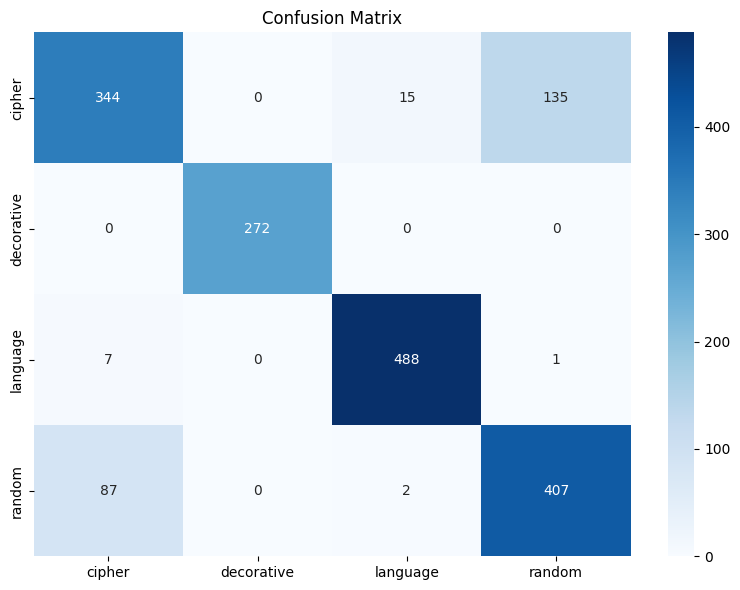


Feature Importance:
   1. bigram_entropy_ratio     : 0.2640
   2. trigram_llh              : 0.1533
   3. ioc                      : 0.1429
   4. cond_entropy             : 0.0887
   5. max_lang_bigram_llh      : 0.0682
   6. zipf_slope               : 0.0639
   7. hapax_ratio              : 0.0478
   8. bigram_llh               : 0.0454
   9. entropy                  : 0.0430
  10. ttr                      : 0.0370
  11. seq_length               : 0.0187
  12. normalized_entropy       : 0.0137
  13. positional_bias          : 0.0135

Accuracy by length:
length_group
5-15       0.8723
16-25      0.9207
26-55      0.9561
56-105     0.9893
106-200    0.9858

Accuracy by label+length:
label       length_group
cipher      5-15            0.714
            16-25           0.803
            26-55           0.871
            56-105          0.967
            106-200         0.950
decorative  5-15            1.000
            16-25           1.000
            26-55           1.000
           

In [42]:
# CELL 8: XGBoost Classifier

import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt, pickle

X    = df[FEATURE_COLS].values
y    = df['label'].values
le   = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"Classes: {list(le.classes_)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Train with early stopping
clf_es = xgb.XGBClassifier(
    n_estimators=1000, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, eval_metric='mlogloss', early_stopping_rounds=30,
    random_state=42, device='cuda'
)
clf_es.fit(X_train, y_train, eval_set=[(X_test,y_test)], verbose=100)
best_iter = clf_es.best_iteration
print(f"\nBest iteration: {best_iter}")

y_pred = clf_es.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test,y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# CV with fixed estimators
clf = xgb.XGBClassifier(
    n_estimators=best_iter, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, eval_metric='mlogloss', random_state=42, device='cuda'
)
clf.fit(X_train, y_train, verbose=False)
cv = cross_val_score(clf, X, y_enc, cv=5, scoring='accuracy')
print(f"5-Fold CV: {[f'{s:.4f}' for s in cv]}")
print(f"CV Mean  : {cv.mean():.4f} ± {cv.std():.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/visualizations/confusion_matrix.png', dpi=100)
plt.show()

# Feature importance
imp     = clf.feature_importances_
indices = imp.argsort()[::-1]
print("\nFeature Importance:")
for i, idx in enumerate(indices):
    print(f"  {i+1:2d}. {FEATURE_COLS[idx]:<25}: {imp[idx]:.4f}")

# Length analysis
df['pred']    = le.inverse_transform(clf.predict(X))
df['correct'] = (df['label'] == df['pred'])
df['len_raw'] = df['seq_length'].apply(lambda x: int(math.exp(x)))
df['length_group'] = pd.cut(
    df['len_raw'], bins=[0,15,25,55,105,210],
    labels=['5-15','16-25','26-55','56-105','106-200']
)
print("\nAccuracy by length:")
print(df.groupby('length_group', observed=True)['correct'].mean().round(4).to_string())
print("\nAccuracy by label+length:")
print(df.groupby(['label','length_group'], observed=True)['correct'].mean().round(3).to_string())

with open('/kaggle/working/checkpoints/classifier.pkl','wb') as f: pickle.dump(clf, f)
with open('/kaggle/working/checkpoints/label_encoder.pkl','wb') as f: pickle.dump(le, f)
print("\nSaved.")

In [43]:
# CELL 9: Interactive Test

CONFIDENCE_THRESHOLD = 0.55
MIN_RELIABLE_LENGTH  = 20

def classify_sequence(sequence):
    if len(sequence) < 2: return None
    sequence = [min(max(s,0), VOCAB_SIZE-1) for s in sequence]
    features = extract_all_features({'ids': sequence})
    X_inp    = np.array([[features[f] for f in FEATURE_COLS]])
    pred_idx = clf.predict(X_inp)[0]
    pred_lbl = le.inverse_transform([pred_idx])[0]
    pred_prb = clf.predict_proba(X_inp)[0]
    proba    = dict(zip(le.classes_, pred_prb))
    conf     = pred_prb.max()
    lang_scr = proba['language']
    uncertain = conf < CONFIDENCE_THRESHOLD or len(sequence) < MIN_RELIABLE_LENGTH

    return {
        'prediction'   : pred_lbl,
        'confidence'   : conf,
        'probabilities': proba,
        'language_score': lang_scr,
        'is_uncertain' : uncertain,
        'length'       : len(sequence),
        'features'     : features,
    }

def print_result(result, text=None):
    if not result:
        print("Too short.")
        return
    pred  = result['prediction']
    conf  = result['confidence']
    score = result['language_score']
    unc   = result['is_uncertain']
    bar   = '█'*int(score*30) + '░'*(30-int(score*30))
    if text:
        print(f"Text           : '{text[:60]}{'...' if len(text)>60 else ''}'")
    print(f"Length         : {result['length']} symbols")
    print(f"Language Score : [{bar}] {score*100:.1f}%")
    if unc:
        if result['length'] < MIN_RELIABLE_LENGTH:
            print("⚠️  Short sequence — may be unreliable")
        if conf < CONFIDENCE_THRESHOLD:
            print(f"⚠️  Low confidence ({conf*100:.1f}%) — UNCERTAIN")
        print(f"Prediction     : {pred.upper()} ({conf*100:.1f}%) [UNCERTAIN]")
    else:
        print(f"Prediction     : {pred.upper()} ({conf*100:.1f}%) ✅")
    print("\nProbabilities:")
    for cls in sorted(result['probabilities'], key=result['probabilities'].get, reverse=True):
        p   = result['probabilities'][cls]
        bar = '█'*int(p*30)
        print(f"  {cls:<12}: {p*100:5.1f}%  {bar}")
    f = result['features']
    print(f"\nKey features:")
    print(f"  bigram_llh    : {f['bigram_llh']:.4f}")
    print(f"  trigram_llh   : {f['trigram_llh']:.4f}")
    print(f"  entropy       : {f['entropy']:.4f}")
    print(f"  ioc           : {f['ioc']:.4f}")
    print("-"*55)

def interactive_test():
    print("="*55)
    print("LANGUAGE-LIKENESS CLASSIFIER (Bigram/Trigram Model)")
    print("Type English text or IDs | 'quit' to exit")
    print("="*55)
    while True:
        ui = input("\nEnter text or IDs: ").strip()
        if ui.lower() == 'quit': break
        if not ui: continue
        parts  = ui.split()
        is_ids = all(p.isdigit() for p in parts)
        print()
        if is_ids:
            seq = [int(p) for p in parts]
            print_result(classify_sequence(seq))
        else:
            clean = ui.lower().replace(' ','')
            seq   = [char_to_id[c] for c in clean if c in char_to_id]
            print_result(classify_sequence(seq), text=ui)

interactive_test()

LANGUAGE-LIKENESS CLASSIFIER (Bigram/Trigram Model)
Type English text or IDs | 'quit' to exit



Enter text or IDs:  In the notebook editor, look at the right-hand sidebar. Under the Data pane, you should see an Output section  Expand /kaggle/working to see a list of your saved files



Text           : 'In the notebook editor, look at the right-hand sidebar. Unde...'
Length         : 132 symbols
Language Score : [█████████████████████████████░] 99.8%
Prediction     : LANGUAGE (99.8%) ✅

Probabilities:
  language    :  99.8%  █████████████████████████████
  cipher      :   0.1%  
  random      :   0.1%  
  decorative  :   0.0%  

Key features:
  bigram_llh    : -2.5881
  trigram_llh   : -2.3215
  entropy       : 4.0567
  ioc           : 0.0640
-------------------------------------------------------



Enter text or IDs:  The UIU Data Science Club is bringing back its flagship event to push your data skills beyond the limits! We are thrilled to announce



Text           : 'The UIU Data Science Club is bringing back its flagship even...'
Length         : 109 symbols
Language Score : [█████████████████████████████░] 98.8%
Prediction     : LANGUAGE (98.8%) ✅

Probabilities:
  language    :  98.8%  █████████████████████████████
  cipher      :   1.0%  
  random      :   0.1%  
  decorative  :   0.1%  

Key features:
  bigram_llh    : -2.7232
  trigram_llh   : -2.6141
  entropy       : 4.1437
  ioc           : 0.0559
-------------------------------------------------------



Enter text or IDs:  dfhgdf ieurlq ;aowdh xzvb liweu oiuewy jhg mnnb ;laqowiru uyrfdbdv kjdddhg awiuery lriugtnjbvkdfj lghiuulwuuuuuu liaufhyuerhftlihg ldfhvvbmnvbakgftewi ileuyreliueyopqierueioyre fkkkkkhbvdddalskrfhlakufhuieryhf kufhkdjlvhcnbvlkdfjlkjhriu eurutfwiouweoiyrewufhdbfvndbvkjhglag



Text           : 'dfhgdf ieurlq ;aowdh xzvb liweu oiuewy jhg mnnb ;laqowiru uy...'
Length         : 252 symbols
Language Score : [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.1%
Prediction     : CIPHER (99.6%) ✅

Probabilities:
  cipher      :  99.6%  █████████████████████████████
  random      :   0.3%  
  language    :   0.1%  
  decorative  :   0.1%  

Key features:
  bigram_llh    : -4.5558
  trigram_llh   : -5.4421
  entropy       : 4.2925
  ioc           : 0.0546
-------------------------------------------------------



Enter text or IDs:  Kaggle can feel a bit overwhelming at first, but we don't want that to hold you back. To ensure everyone is fully prepared before the competition begins,



Text           : 'Kaggle can feel a bit overwhelming at first, but we don't wa...'
Length         : 123 symbols
Language Score : [█████████████████████████████░] 99.6%
Prediction     : LANGUAGE (99.6%) ✅

Probabilities:
  language    :  99.6%  █████████████████████████████
  cipher      :   0.2%  
  decorative  :   0.2%  
  random      :   0.1%  

Key features:
  bigram_llh    : -2.6208
  trigram_llh   : -2.3441
  entropy       : 4.1736
  ioc           : 0.0596
-------------------------------------------------------



Enter text or IDs:  quit


In [44]:
# COMPREHENSIVE TEST — Model train হয়নি এমন সব ধরনের input

print("=" * 60)
print("LANGUAGE TESTS")
print("=" * 60)

language_tests = {
    'English (casual)': [
        "my name is siam howladar",
        "i love football very much",
        "yesterday i went to market with friends",
        "she is one of the best students",
    ],
    'English (technical)': [
        "XGBoost is an optimized machine learning library",
        "neural networks learn from data automatically",
        "python is a popular programming language",
        "deep learning requires large amounts of data",
    ],
    'English (formal)': [
        "the committee has decided to postpone the meeting",
        "pursuant to the regulations of the institution",
        "it is hereby declared that all members must comply",
    ],
    'English (names/places)': [
        "mahfuz chowdhury is from dhaka bangladesh",
        "sristy akter studies at united international university",
        "nahid sir is our thesis supervisor",
    ],
    'Turkish': [
        "merhaba nasılsın bugün",
        "istanbul büyük bir şehirdir",
        "türkiye güzel bir ülkedir",
    ],
    'Finnish': [
        "hyvää huomenta kaikille",
        "helsinki on suomen pääkaupunki",
        "suomi on kaunis maa",
    ],
    'Spanish': [
        "buenos días como estás",
        "madrid es una ciudad hermosa",
        "me llamo juan y soy estudiante",
    ],
    'Latin': [
        "veni vidi vici caesar dixit",
        "carpe diem quam minimum credula postero",
        "cogito ergo sum rene descartes",
    ],
}

for category, texts in language_tests.items():
    print(f"\n--- {category} ---")
    for text in texts:
        clean = text.lower().replace(' ', '')
        seq   = [char_to_id[c] for c in clean if c in char_to_id]
        if seq:
            r      = classify_sequence(seq)
            status = '✅' if r['prediction'] == 'language' else '❌'
            print(f"{status} [{len(seq):3d}] '{text[:45]}'")
            print(f"      → {r['prediction'].upper()} ({r['confidence']*100:.1f}%) | "
                  f"lang={r['language_score']*100:.1f}%")

print("\n" + "=" * 60)
print("CIPHER TESTS (various types)")
print("=" * 60)

cipher_tests = {
    'Caesar (+3)': [
        "wkh txlfn eurzq ira mxpsv ryhu wkh odcb grj",
        "pb qdph lv vldp krzodddu",
    ],
    'Caesar (+13 / ROT13)': [
        "gur dhvpx oebja sbk whzcf bire gur ynml qbt",
        "uryyb zl anzr vf fvnz",
    ],
    'Vigenere': [
        "lxfopvefrnhr",
        "rijvs uyvjn atn lxrp",
    ],
    'Substitution (Zodiac-like)': [
        "xbq azp lmk wrt ycd efg hij",
        "zyx wvu tsr qpo nml kji hgf",
    ],
    'Reversed text': [
        "god eht revo spmuj xof nworb kciuq eht",
        "maidlowalh mais si eman ym",
    ],
}

for category, texts in cipher_tests.items():
    print(f"\n--- {category} ---")
    for text in texts:
        clean = text.lower().replace(' ', '')
        seq   = [char_to_id[c] for c in clean if c in char_to_id]
        if seq:
            r      = classify_sequence(seq)
            status = '✅' if r['prediction'] == 'cipher' else '❌'
            print(f"{status} [{len(seq):3d}] '{text[:45]}'")
            print(f"      → {r['prediction'].upper()} ({r['confidence']*100:.1f}%) | "
                  f"lang={r['language_score']*100:.1f}%")

print("\n" + "=" * 60)
print("RANDOM TESTS")
print("=" * 60)

import random
random.seed(99)

random_tests = [
    [random.randint(0, VOCAB_SIZE-1) for _ in range(30)],
    [random.randint(0, VOCAB_SIZE-1) for _ in range(50)],
    [random.randint(0, VOCAB_SIZE-1) for _ in range(100)],
]

for ids in random_tests:
    r      = classify_sequence(ids)
    status = '✅' if r['prediction'] == 'random' else '❌'
    print(f"{status} [{len(ids):3d} symbols] → {r['prediction'].upper()} "
          f"({r['confidence']*100:.1f}%) | lang={r['language_score']*100:.1f}%")

print("\n" + "=" * 60)
print("DECORATIVE TESTS")
print("=" * 60)

decorative_tests = [
    [0, 1] * 20,           # ababab...
    [5] * 30,              # ffffff...
    [2, 7, 2, 7] * 10,    # chch...
    [0, 1, 2] * 15,       # abcabc...
    [10, 10, 11, 11] * 10, # kkll...
]

for ids in decorative_tests:
    chars  = ''.join(id_to_char.get(i, '?') for i in ids[:12])
    r      = classify_sequence(ids)
    status = '✅' if r['prediction'] == 'decorative' else '❌'
    print(f"{status} [{len(ids):3d}] pattern='{chars}...' → "
          f"{r['prediction'].upper()} ({r['confidence']*100:.1f}%)")

print("\n" + "=" * 60)
print("EDGE CASES")
print("=" * 60)

edge_cases = [
    ("Very short English", "hi"),
    ("Single word", "football"),
    ("Numbers in text", "the 4 friends went to restaurant"),
    ("Mixed nonsense", "asdfjkl qweruio zxcvbnm"),
    ("Repeated English word", "the the the the the the the the"),
    ("Bengali name in English", "chowdhury mahfuzur rahman"),
    ("Brand names", "coca cola pepsi sprite fanta"),
    ("Code-like", "forloopinrangeten printx"),
]

for label, text in edge_cases:
    clean = text.lower().replace(' ', '')
    seq   = [char_to_id[c] for c in clean if c in char_to_id]
    if seq:
        r = classify_sequence(seq)
        print(f"[{label}]")
        print(f"  '{text}'")
        print(f"  → {r['prediction'].upper()} ({r['confidence']*100:.1f}%) | "
              f"lang={r['language_score']*100:.1f}% | len={len(seq)}")

LANGUAGE TESTS

--- English (casual) ---
❌ [ 20] 'my name is siam howladar'
      → CIPHER (59.2%) | lang=39.2%
✅ [ 21] 'i love football very much'
      → LANGUAGE (99.5%) | lang=99.5%
✅ [ 33] 'yesterday i went to market with friends'
      → LANGUAGE (99.7%) | lang=99.7%
✅ [ 25] 'she is one of the best students'
      → LANGUAGE (99.7%) | lang=99.7%

--- English (technical) ---
✅ [ 42] 'XGBoost is an optimized machine learning libr'
      → LANGUAGE (99.5%) | lang=99.5%
✅ [ 40] 'neural networks learn from data automatically'
      → LANGUAGE (93.7%) | lang=93.7%
✅ [ 35] 'python is a popular programming language'
      → LANGUAGE (99.6%) | lang=99.6%
✅ [ 38] 'deep learning requires large amounts of data'
      → LANGUAGE (99.7%) | lang=99.7%

--- English (formal) ---
✅ [ 42] 'the committee has decided to postpone the mee'
      → LANGUAGE (99.8%) | lang=99.8%
✅ [ 40] 'pursuant to the regulations of the institutio'
      → LANGUAGE (99.8%) | lang=99.8%
✅ [ 42] 'it is hereby declared th